<h1 style="display:flex; align-items:center; line-height:1; margin:0;">
  <img src="rwcircle.png" style="height:36px; width:36px; border-radius:50%; flex-shrink:0;">
  <span style="padding-top:2px; margin-left:10px;"><b>Calculation of number of eclipses per target</b>: statistical power and N-sigmas</span>
</h1>

***
**Author**: Nestor Espinoza (nespinoza@stsci.edu) | **Date of last change**: March 3rd, 2026

## Summary
In this notebook, we study the number of eclipses needed, for each target, to reach a given statistical power at a given number-of-sigma detection for both Checkpoint 1 and Checkpoint 2 in the Rocky Worlds DDT strategy.

## Imports
 We will need three simple imports for this notebook:
- *numpy* to handle array functions,
- *matplotlib.pyplot* for plotting data,
- *seaborn* for giving publication-quality style to plots 

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection

import seaborn as sns
sns.set_style('ticks')

import matplotlib as mpl 

We will be doing some random number generation, so we set the seed:

In [2]:
np.random.seed(127)

And we define some plotting setups:

In [3]:
# And also Arial fonts :-):
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# No top and right edges:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

Finally, we make use of partial functions quite a bit in this notebook, so import those as well:

In [4]:
from functools import partial

***

<a id="general-simulation-setup"></a>
## 1. General simulation setup

First, let's extract all relevant calculations done by the Rocky Worlds DDT CIT itself on the 9 targets of the program:

In [5]:
planet_names, times_per_int, precisions_per_int, eclipse_durations, observing_times, \
eclipse_errors, fpfs_rock, fpfs_co2 = np.genfromtxt(
                                          'calculations.csv',
                                          skip_header = 1,
                                          usecols = (0, 1, 4, 5, 6, 7, 9, 10),
                                          delimiter=',',
                                          dtype=None,
                                          encoding=None,
                                          unpack=True,
                                          autostrip=True,
                                      )

Let's put all this information in an easy-to-reference dictionary:

In [6]:
CIT_calculations = {}
for i in range( len(planet_names) ):

    CIT_calculations[planet_names[i]] = {}
    CIT_calculations[planet_names[i]]['time per integration'] = times_per_int[i]
    CIT_calculations[planet_names[i]]['precision per integration'] = precisions_per_int[i]
    CIT_calculations[planet_names[i]]['eclipse duration'] = eclipse_durations[i]
    CIT_calculations[planet_names[i]]['observing time'] = observing_times[i]
    CIT_calculations[planet_names[i]]['eclipse error'] = eclipse_errors[i]
    CIT_calculations[planet_names[i]]['bare rock depth'] = fpfs_rock[i]
    CIT_calculations[planet_names[i]]['CO2 depth'] = fpfs_co2[i]

And let's plot this information for each target on a sort-of-summary plot:

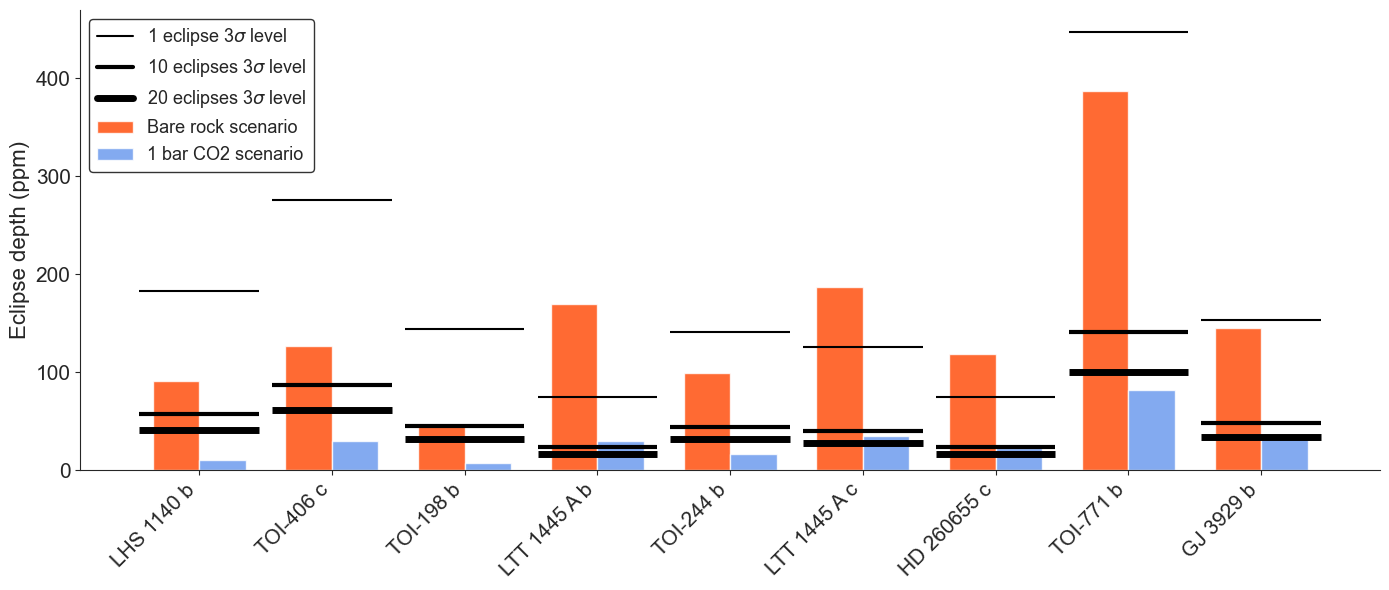

In [7]:
# Get the target names:
targets = list(CIT_calculations.keys())

# Extract values from dictionary:
bare_depths = np.array([CIT_calculations[t]['bare rock depth'] for t in targets])
co2_depths  = np.array([CIT_calculations[t]['CO2 depth'] for t in targets])
errors      = np.array([CIT_calculations[t]['eclipse error'] for t in targets])

# Set 3-sigma detection thresholds:
sig3_1  = 3 * errors 
sig3_10 = 3 * errors / np.sqrt(10)
sig3_20 = 3 * errors / np.sqrt(20)

# Now get the plot done:
x = np.arange(len(targets))
width = 0.35

plt.figure(figsize=(14,6))

# Plot the bars themselves:
plt.bar(x - width/2, bare_depths, width, label="Bare rock scenario", alpha=0.8, color = 'orangered')
plt.bar(x + width/2, co2_depths,  width, label="1 bar CO2 scenario", alpha=0.8, color = 'cornflowerblue')

# Plot 3-sigma thresholds:
for i in range(len(targets)):
    plt.hlines(sig3_1[i],  x[i]-0.45, x[i]+0.45, linestyle="-", linewidth=1.5, label=None, color = 'k')
    plt.hlines(sig3_10[i], x[i]-0.45, x[i]+0.45, linestyle="-", linewidth=3.0, label=None, color = 'k')
    plt.hlines(sig3_20[i], x[i]-0.45, x[i]+0.45, linestyle="-",  linewidth=5.0, label=None, color = 'k')

# Define legend:
plt.plot([], [], linestyle="-", color="k", lw = 1.5, label=r"1 eclipse 3$\sigma$ level")
plt.plot([], [], linestyle="-", color="k", lw = 3.0, label=r"10 eclipses 3$\sigma$ level")
plt.plot([], [], linestyle="-",  color="k", lw = 5.0, label=r"20 eclipses 3$\sigma$ level")

# Define axes:
plt.xticks(x, targets, rotation=45, ha="right", fontsize = 15)
plt.yticks(fontsize = 15)
plt.ylabel("Eclipse depth (ppm)", fontsize = 16)
leg = plt.legend(loc = 'upper left', fontsize = 13, frameon=True)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1)

plt.tight_layout()
plt.show()

This plot is interesting as it encapsulates a lot of information about the Rocky Worlds DDT targets. For instance, only a few eclipses are needed for a few targets in order to detect an eclipse in the bare rock case (LTT 1445 A b, LTT 1445 A c, HD 260655 c, GJ 3929 b), while others require substantial investment just to detect the bare rock case --- most notably TOI-198 b, which needs of order 10 eclipses to make the detection happen at 3$\sigma$.

Next, as in Appendix B, we create a function that simulates an eclipse time-series that we will use later to calculate number of eclipses needed for different tests. Why we do this in this case when some of those calculations have already been done by the CIT will become clear in the next few sections. 

One difference with respect to the previous notebook is that here we write the function as a function of integration cadence (in seconds), total observing time (in hours) and eclipse duration (in hours). Note in the Appendix B notebook we did this as a function of in-transit and out-of-transit points --- here we just do some conversion from time to those parameters instead:

In [8]:
def make_eclipse(time_per_integration, observing_time, eclipse_duration, depth, noise):
    """
    time_per_integration:     time per integration in seconds associated to light curve noise.
    observing_time:           total observing time in hours.
    eclipse_duration:         duration of the eclipse in hours.
    depth:                    eclipse depth in ppm.
    noise:                    light curve noise (i.e., per integration scatter) in ppm.
    """

    Ntotal = int( np.floor( observing_time * 3600. / time_per_integration ) )
    Nin = int( np.floor( eclipse_duration * 3600. / time_per_integration ) )
    Nout = Ntotal - Nin
    
    model = np.ones( Ntotal ) + (depth * 1e-6)                   # Set all value to out-of-eclipse values
    model[int(Nout/2):-int(Nout/2)] = 1.                         # Set in-eclipse points to stellar flux
    
    return model, model + np.random.normal(0, noise, Ntotal) * 1e-6     # Return noisy light curve

Let's check it works --- let's ingest properties for GJ 3929 b:

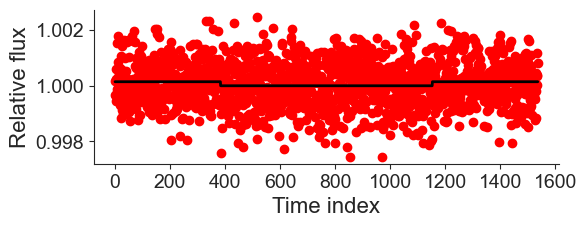

In [9]:
time_per_integration = CIT_calculations['GJ 3929 b']['time per integration']
observing_time = CIT_calculations['GJ 3929 b']['observing time']
eclipse_duration = CIT_calculations['GJ 3929 b']['eclipse duration']
depth = CIT_calculations['GJ 3929 b']['bare rock depth']
noise = CIT_calculations['GJ 3929 b']['precision per integration']
model, data = make_eclipse(time_per_integration, observing_time, eclipse_duration, depth, noise)

plt.figure( figsize=(6, 2) )

plt.plot( data , 'ro')
plt.plot( model , '-', lw = 2, color = 'black')

plt.ticklabel_format(useOffset=False)

plt.xlabel('Time index', fontsize = 16)
plt.ylabel('Relative flux', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

Works! Now let's build a function that returns us the eclipse depth and error on this:

In [10]:
def get_depth(data, time_per_integration, observing_time, eclipse_duration):

    Ntotal = int( np.floor( observing_time * 3600. / time_per_integration ) )
    Nin = int( np.floor( eclipse_duration * 3600. / time_per_integration ) )
    Nout = Ntotal - Nin    

    # Get data in and out of eclipse:
    data_in_eclipse = data[int(Nout/2):-int(Nout/2)]
    data_out_of_eclipse = np.append( data[:int(Nout/2)-1], data[-int(Nout/2):] )

    # Apply mean and variance rules:
    depth = ( np.sum(data_out_of_eclipse) / len(data_out_of_eclipse) ) - \
            ( np.sum(data_in_eclipse) / len(data_in_eclipse) )

    error = np.sqrt( 
            np.var(data_out_of_eclipse) * ( 1. / len(data_out_of_eclipse)) + \
            np.var(data_in_eclipse) * ( 1. / len(data_in_eclipse) ) \
            )

    return depth * 1e6, error * 1e6

Let's test this gives back what is expected via Monte-Carlo simulations:

In [11]:
nsim = 5000
depths = np.zeros(nsim)
errors = np.zeros(nsim)

for i in range(nsim):

    _, data = make_eclipse(time_per_integration, observing_time, eclipse_duration, depth, noise)
    depths[i], errors[i] = get_depth(data, time_per_integration, observing_time, eclipse_duration)

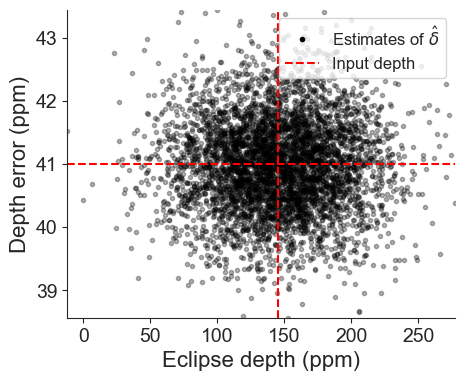

In [12]:
plt.figure( figsize=(5, 4) )

Ntotal = int( np.floor( observing_time * 3600. / time_per_integration ) )
Nin = int( np.floor( eclipse_duration * 3600. / time_per_integration ) )
Nout = Ntotal - Nin    

expected_error = noise * np.sqrt( (1. / Nout) + (1. / Nin) )

plt.plot(depths, errors, '.', color = 'black', alpha = 0.3)
plt.plot([0,0],[0,0], '.', color = 'black', label = r'Estimates of $\hat{\delta}$')
plt.plot([depth, depth], [np.min(errors), np.max(errors)], 'r--', label = 'Input depth')
plt.plot([np.min(depths), np.max(depths)], [expected_error, expected_error], 'r--')
plt.xlim(np.min(depths), np.max(depths))
plt.ylim(np.min(errors), np.max(errors))

plt.xlabel('Eclipse depth (ppm)', fontsize = 16)
plt.ylabel('Depth error (ppm)', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 12, loc = 'upper right')
plt.show()

Neat! It works. You might be wondering: "but hey, the depth error here is 41 ppm for GJ 3929 b --- wasn't it 51 ppm in the histogram above?". That's correct --- the reason is that the CIT calculations have included a fudge factor of $\times1.25$ that is multiplied to the error calculated from the ETC, to account for the fact that real data has some extra correlated noise that inflates errorbars a bit. Indeed, if we multiply the expectation above by $\times1.25$, we get

In [13]:
print(int( expected_error * 1.25 ), 'ppm,')

51 ppm,


which is exactly what appears in the CIT calculations. Next, let's do some simulations with these numbers to understand what an eclipse survey like the Rocky Worlds DDT can do --- and to define the number of eclipses to reach different goals for each target.

## 2. Simulations
### 2.1 The case of GJ 3929 b

#### 2.1.1 Detecting a bare rock
Given GJ 3929 b is the target for which already 4 eclipses have been obtained, this sets a very interesting starting point to perform some calculations and simulations we can explore in light of the real data obtained for it, and what to expect from such a dataset. First, let's extract the relevant information for this target:

In [14]:
target = 'GJ 3929 b'

time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

In [the first section of this notebook](#general-simulation-setup), we already saw that a single eclipse was insuficient to detect the bare rock case with a single eclipse. This is because the bare rock eclipse depth is

In [15]:
print(bare_depth, 'ppm')

145 ppm


And the single-eclipse error is

In [16]:
print(eclipse_error, 'ppm.')

51 ppm.


However, in theory, two measurements should be enough because then the error of the mean between those two measurements should be

In [17]:
print(int( eclipse_error / np.sqrt(2)) , 'ppm,')

36 ppm,


and $N_\sigma$ = (Target eclipse depth) / (Error after 2 visits) = 145 / 36 is about 4 --- so if all those numbers were exact, we should be able to detect the bare rock case at 4$\sigma$ (> $3\sigma$) by measuring two eclipse events. This was the reason why, in the Rocky Worlds DDT, the number of eclipses for Checkpoint 1 was decided at 2 observations. Life and randomness, of course, do not deliver exact values, and in not all the universes the CIT team would have been unable to claim a bare rock after 2 eclipses even if the bare rock case was real. We explore the implications of this in the next subsection.

#### 2.1.2 Statistical power analysis and detection of bare rocks

To motivate this next section, let us simulate 10,000 random draws with the assumed bare rock case and noise properties for GJ 3929 b (i.e., including the $\times1.25$ error fudge factor). If in each of those 10,000 random draws we simulate 2 eclipses --- in how many of those are we able to claim a bare rock?

In [18]:
nsimulations = 10000
detected = 0
for i in range(nsimulations):

    # Simulate 2 draws from the target eclipse depth:
    eclipse_depths = np.random.normal(bare_depth, eclipse_error, 2)

    # Let's compute the combined eclipse depth:
    combined_depth = np.mean(eclipse_depths)
    combined_depth_error = eclipse_error / np.sqrt(2)

    # Did we manage to detect the eclipse in this bare rock case at, at least, 3-sigma?
    if combined_depth - 3.*combined_depth_error > 0.:

        detected += 1

print( 'Eclipse detected in {0:.2f}% of the simulations.'.format( ( detected / nsimulations ) * 100. ) )

Eclipse detected in 84.53% of the simulations.


That's actually quite good! In about 85% of the simulations we are able to claim this detection. This is what we call the **statistical power** of this threshold/sample/test. Note, in this case, we could _semi-analytically_ have obtained this detection probability --- because the test we are doing (Combined Depth > $3 \times $ Combined Error) is the same as testing whether a gaussian with unitary variance and mean equal to (Bare Rock / Combined Error) is larger than 3:

In [19]:
print( '{0:.2f}% of detections'.format(( 1. - scipy.stats.norm.cdf(3, loc = bare_depth/combined_depth_error) ) * 100) )

84.63% of detections


But --- what if there was actually _no_ eclipse in the data? How many times we would have _falsely_ claimed a detection? Let's check this with a simple simulation again:

In [20]:
detected = 0
for i in range(nsimulations):

    # Simulate 2 draws from the target eclipse depth:
    eclipse_depths = np.random.normal(0, eclipse_error, 2)

    # Let's compute the combined eclipse depth:
    combined_depth = np.mean(eclipse_depths)
    combined_depth_error = eclipse_error / np.sqrt(2)

    # Did we manage to detect the eclipse in this bare rock case at, at least, 3-sigma?
    if combined_depth - 3.*combined_depth_error > 0.:

        detected += 1

print( 'Eclipse detected in {0:.2f}% of the simulations.'.format( ( detected / nsimulations ) * 100. ) )

Eclipse detected in 0.17% of the simulations.


This is actually what we were expecting for a 3$\sigma$ threshold, which we can also compute directly without simulations. Under the null hypothesis of no eclipse, a 3$\sigma$ threshold like the one imposed above should give back, assuming gaussian random variables, about:

In [21]:
print( '{0:.3f}% false detections'.format((1. - scipy.stats.norm.cdf(3)) * 100) )

0.135% false detections


which is very close to what we get in our simulation.

These simulations, however, have a catch, which is also one of the reasons why their results can be computed semi-analytically: they all assume the errors of the eclipse depth on each observation are perfectly known. 

What if they are not? Instead of trying to figure out the distribution of the error, we use the lightcurve simulator above to extract the eclipse depths and errors from each eclipse. The reason for using it is that the function can be later replaced to incorporate any kind of extra modelling done from the lightcurve-to-eclipse stage by simply modifying this Python notebook. 

Let us make a generic function that, given an $N\sigma$ and a number of eclipses (and all the properties of those eclipses), it returns the eclipse detection rate given a true depth:

In [22]:
def checkpoint1_detection_rate(neclipses, true_depth, time_per_integration, observing_time, eclipse_duration, noise, 
                               factor = 1.25, nsimulations = 10000, Nsigma = 3):
    
    detected = 0
    depths, errors = np.zeros(neclipses), np.zeros(neclipses)
    for i in range(nsimulations):
    
        # Simulate neclipses draws from the target eclipse depths;
        # we apply the ( by default x1.25) noise increase factor to the lightcurve errors:
        for k in range(neclipses):
    
            _, data = make_eclipse(time_per_integration, observing_time, eclipse_duration, true_depth, noise * factor)
            depths[k], errors[k] = get_depth(data, time_per_integration, observing_time, eclipse_duration)
    
        # Let's compute the combined eclipse depths via weighted averages:
        w = 1.0 / ( errors**2 )
        
        combined_depth = np.sum(w * depths) / np.sum(w)
        combined_depth_error = 1.0 / np.sqrt(np.sum(w))
    
        # Did we manage to detect the eclipse in this bare rock case at, at least, 3-sigma?
        if combined_depth - Nsigma * combined_depth_error > 0.:
    
            detected += 1

    return ( detected / nsimulations ) * 100.

Let's test this for our eclipse detection exercise when the bare rock case is the true depth to estimate its statistical power:

In [23]:
# Create a partial function for GJ 3929 b's Checkpoint 1 detection rate:
gj3929_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                            time_per_integration = time_per_integration, 
                                            observing_time = observing_time, 
                                            eclipse_duration = eclipse_duration, 
                                            noise = noise
                                           )

# Estimate GJ 3929 b's "default" statistical power:
statistical_power = gj3929_checkpoint1_detection_rate(neclipses = 2, true_depth = bare_depth)

print( 'Eclipse detected in {0:.2f}% of the simulations.'.format( statistical_power ) )

Eclipse detected in 83.65% of the simulations.


Neat! Still pretty close to what we obtained before in the gaussian case. What about the false detection rate?

In [24]:
false_positive_rate = gj3929_checkpoint1_detection_rate(neclipses = 2, true_depth = 0)
print( 'Eclipse detected in {0:.2f}% of the simulations.'.format( false_positive_rate ) )

Eclipse detected in 0.05% of the simulations.


Also pretty close to the expected gaussian case! This is a good sign that our simulations are on point. Let's keep moving with what the CIT considers as "Checkpoint 2" next.

#### 2.1.3 Differentiating bare rocks from atmospheres

For the CIT, Checkpoint 2 is defined as the number of eclipses needed to "(...) differentiate between a bare rock and a (CO$_2$-dominated) atmosphere at the 3$\sigma$ level". Let's create a function that, as above, calculates detection rates to estimate the statistical power and the false detection rates for a test like this using simulations. 

First, let's create a generic function that estimates detection rates for this Checkpoint 2 case:

In [25]:
def checkpoint2_detection_rate(neclipses, true_depth, time_per_integration, observing_time, eclipse_duration, noise,
                               target_depth,
                               factor = 1.25, nsimulations = 10000, Nsigma = 3):
    
    detected = 0
    depths, errors = np.zeros(neclipses), np.zeros(neclipses)

    # Determine if this is the case of the bare rock being the true depth. 
    # If not, condition below changes to claim a detection:
    bare_rock_true_case = true_depth > target_depth 
        
    for i in range(nsimulations):
    
        # Simulate neclipses draws from the target eclipse depths;
        # we apply the ( by default x1.25) noise increase factor to the lightcurve errors:
        for k in range(neclipses):
    
            _, data = make_eclipse(time_per_integration, observing_time, eclipse_duration, true_depth, noise * factor)
            depths[k], errors[k] = get_depth(data, time_per_integration, observing_time, eclipse_duration)
    
        # Let's compute the combined eclipse depths via weighted averages:
        w = 1.0 / ( errors**2 )
        
        combined_depth = np.sum(w * depths) / np.sum(w)
        combined_depth_error = 1.0 / np.sqrt(np.sum(w))
    
        # Did we manage to differentiate between a bare rock and a CO2-dominated atmosphere at 3-sigma?
        if bare_rock_true_case:

            # In this case, true depth is the bare rock; target depth is CO2-dominated. 
            # We are asking: if the real eclipse is generated by a bare rock, in how many 
            # simulations we rule out the CO2-dominated case at Nsigma-sigma, 
            # i.e., observed depth - Nsigma * (observed error) > CO2 depth: 
            if combined_depth - Nsigma * combined_depth_error > target_depth:
        
                detected += 1

        else:
            # In this case, true depth is the CO2-dominated atmosphere. 
            # We are asking: if the real eclipse is generated by a CO2-dominated atmosphere, 
            # in how many simulations we rule out the bare rock case at Nsigma-sigma, 
            # i.e., observed depth + Nsigma * (observed error) < bare rock depth: 
            if combined_depth + Nsigma * combined_depth_error < target_depth:

                detected += 1
            

    return ( detected / nsimulations ) * 100.

Let's first check the detection rate and false positive rates if we only did 2 eclipses, like above. Let's first create a partial function on which to do our experiments:

In [26]:
# Create a partial function for GJ 3929 b's Checkpoint 2 detection rate:
gj3929_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                            time_per_integration = time_per_integration, 
                                            observing_time = observing_time, 
                                            eclipse_duration = eclipse_duration, 
                                            noise = noise
                                           )

Now, let's assume the planet is truly a bare rock. In this case, how many times we would have been able to claim to differentiate the observed eclipses from a CO$_2$-dominated atmosphere?

In [27]:
# Estimate GJ 3929 b's 2-eclipse Checkpoint 2 statistical power assuming a bare rock:
statistical_power_checkpoint2 = gj3929_checkpoint2_detection_rate(neclipses = 2, true_depth = bare_depth, target_depth = co2_depth)

print( 'Differentiated CO2 atmospheres in {0:.2f}% of the simulations.'.format( statistical_power_checkpoint2 ) )

Differentiated CO2 atmospheres in 55.42% of the simulations.


That would have been pretty bad! We would have missed around 50% of detections at the 3$\sigma$ level.  What about the other way around: the true depth is a CO2-dominated atmosphere, and we are trying to rule-out a bare rock:

In [28]:
# Estimate GJ 3929 b's 2-eclipse Checkpoint 2 false positive rate:
statistical_power_inverted_checkpoint2 = gj3929_checkpoint2_detection_rate(neclipses = 2, true_depth = co2_depth, target_depth = bare_depth)

print( 'Differentiated bare rock atmospheres in {0:.2f}% of the simulations.'.format( statistical_power_inverted_checkpoint2 ) )

Differentiated bare rock atmospheres in 54.41% of the simulations.


We get a very similar result. In fact, the difference between swapping `true_depth` and `target_depth` comes mostly from Monte Carlo noise. Given how we are simulating our eclipses (via the `make_eclipse` function and estimating depths and errors via the `get_depth` function), both tests _should_ be identical because (a) the combined depth estimates are unbiased (and have expectation values equal to the true depth) and (b) the error on the eclipse depth depends only on the individual light curve errorbars. To see this latter point, note the `get_depth` function estimates the error on the depth $\hat{\sigma}_{\delta}$ from:

$\hat{\sigma}^2_{\delta} = \sigma^2_{out} / N_{out} + \sigma^2_{in} / N_{in}$

which doesn't depend on the actual value of the depth, $\delta$.

This means the detection rate depends only on the difference $\Delta = |\delta_{CO_2} - \delta_{rock}|$, where $\delta_{CO_2}$ is the CO$_2$-dominated eclipse depth and $\delta_{rock}$ is the bare rock depth.

In other words, our statistical power calculations for Checkpoint 2 using either combination give the same result: they mean what fraction of times, if the true depth is a CO$_2$-dominated atmosphere, we would be able to rule out a bare rock, and if the true depth was a bare rock, we would be able to rule out a CO$_2$-dominated atmosphere.

All right --- can we increase the statistical power with, say, 3 eclipses instead to a significantly better value?

In [29]:
# Estimate GJ 3929 b's 2-eclipse Checkpoint 2 statistical power assuming a bare rock, for 3 eclipses
neclipses = 3
statistical_power_checkpoint2_neclipses = gj3929_checkpoint2_detection_rate(neclipses = neclipses, 
                                                                            true_depth = bare_depth, 
                                                                            target_depth = co2_depth)

print( 'Differentiated CO2 atmospheres in {0:.2f}% of the simulations with {1:} eclipses.'.format( 
        statistical_power_checkpoint2_neclipses, neclipses ) )

Differentiated CO2 atmospheres in 79.16% of the simulations with 3 eclipses.


That's better. What about 4?

In [30]:
# Estimate GJ 3929 b's 2-eclipse Checkpoint 2 statistical power assuming a bare rock, for 4 eclipses
neclipses = 4
statistical_power_checkpoint2_neclipses = gj3929_checkpoint2_detection_rate(neclipses = neclipses, 
                                                                            true_depth = bare_depth, 
                                                                            target_depth = co2_depth)

print( 'Differentiated CO2 atmospheres in {0:.2f}% of the simulations with {1:} eclipses.'.format( 
        statistical_power_checkpoint2_neclipses, neclipses ) )

Differentiated CO2 atmospheres in 91.87% of the simulations with 4 eclipses.


Great. It seems like, if our threshold was $> 80\%$ statistical power, 4 is the key number of eclipses to target in order to have a decent statistical power for this test between bare rocks and CO$_2$-dominated atmospheres for GJ 3929 b.

#### 2.1.4 $N-\sigma$, statistical power and number of eclipses

One important lesson from the experiments performed above is that the number of eclipses, the $N\sigma$ threshold one uses and the statistical power are all interconected --- in our experiments above close to gaussian expectations. What is not evident from our experiments above, however, is how much the number of eclipses can jump between different selections/thresholds for $N\sigma$ and the statistical power itself. In this section, we build two-dimensional plots that visually highlight this.

Let's first try this for GJ 3929 b's Checkpoint 1. Let us build a plot that showcases the statistical power in the x-axis, the $N\sigma$ threshold in the y-axis, and with color the number of eclipses needed to reach a given set. We calculate the statistical powers first:

In [31]:
neclipses = np.arange(1, 15, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'gj3929b'
if os.path.exists('sp_ch1_'+sufix+'.npy'):

    statistical_powers = np.load('sp_ch1_'+sufix+'.npy')

else:
    
    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers[i, j] = gj3929_checkpoint1_detection_rate(neclipses = neclipse, true_depth = bare_depth, Nsigma = nsigma)


    np.save('sp_ch1_'+sufix+'.npy', statistical_powers)

And then invert this to get the desired plot:

In [32]:
def draw_discrete_boundaries(ax, Z, x_edges, y_edges, *, color="white", lw=0.8, alpha=0.8):
    """
    Draw boundaries exactly along pcolormesh cell edges where neighboring cells differ.
    Z: (ny, nx) array of discrete values (NaNs allowed).
    x_edges: (nx+1,) array of x cell edges
    y_edges: (ny+1,) array of y cell edges
    """
    Z = np.asarray(Z)
    ny, nx = Z.shape

    segs = []

    # Vertical boundaries: between (i, j-1) and (i, j) at x = x_edges[j]
    for i in range(ny):
        for j in range(1, nx):
            a, b = Z[i, j-1], Z[i, j]
            if np.isnan(a) or np.isnan(b) or a == b:
                continue
            x = x_edges[j]
            y0, y1 = y_edges[i], y_edges[i+1]
            segs.append([(x, y0), (x, y1)])

    # Horizontal boundaries: between (i-1, j) and (i, j) at y = y_edges[i]
    for i in range(1, ny):
        for j in range(nx):
            a, b = Z[i-1, j], Z[i, j]
            if np.isnan(a) or np.isnan(b) or a == b:
                continue
            y = y_edges[i]
            x0, x1 = x_edges[j], x_edges[j+1]
            segs.append([(x0, y), (x1, y)])

    if segs:
        lc = LineCollection(segs, colors=color, linewidths=lw, alpha=alpha)
        ax.add_collection(lc)

def _label_each_cell(ax, req_eclipses, power_grid, nsigmas):
    ny, nx = req_eclipses.shape
    for i in range(ny):
        for j in range(nx):
            v = req_eclipses[i, j]
            if np.isnan(v):
                continue
            ax.text(
                power_grid[j],
                nsigmas[i],
                f"{int(v)}",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
                alpha = 0.5,
                path_effects=[pe.withStroke(linewidth=1, foreground="black", alpha=0.4)]
            )

def plot_eclipses_needed_vs_power(
    statistical_powers,
    nsigmas,
    neclipses,
    power_grid=None,
    *,
    power_bins=41,
    label_mode="cells",        # "none" | "cells"
    show_boundaries=True,
    tick_jump = 1,
    cmap="viridis",
    max_eclipse=None,
    ax=None,
    power_min=None,
    power_max=None,
    title="Checkpoint 1 Eclipses",
):
    statistical_powers = np.asarray(statistical_powers, dtype=float)
    nsigmas = np.asarray(nsigmas, dtype=float)
    neclipses = np.asarray(neclipses, dtype=int)

    # Detect percent scale
    pmax = np.nanmax(statistical_powers)
    percent_scale = (pmax > 1.5)

    if percent_scale:
        if power_min is None: power_min = 0.0
        if power_max is None: power_max = 99.5   # <-- exclude 100%
    else:
        if power_min is None: power_min = 0.0
        if power_max is None: power_max = 0.995  # <-- exclude 1.0

    if percent_scale:
        x_label = "Statistical power (%)"
        if power_grid is None:
            power_grid = np.linspace(np.nanmin(statistical_powers),
                                     np.nanmax(statistical_powers), 400)
    else:
        x_label = "Statistical power"
        if power_grid is None:
            power_grid = np.linspace(np.nanmin(statistical_powers),
                                     np.nanmax(statistical_powers), 400)

    power_grid = np.asarray(power_grid)
    power_grid = power_grid[(power_grid >= power_min) & (power_grid <= power_max)]

    # Coarsen for plotting/labeling if requested
    if power_bins is not None:
        power_grid_plot = np.linspace(power_min, power_max, int(power_bins))
    else:
        power_grid_plot = power_grid

    # Invert: min eclipses to reach each power
    req_eclipses = np.full((len(nsigmas), len(power_grid_plot)), np.nan)

    for i in range(len(nsigmas)):
        row = np.maximum.accumulate(statistical_powers[i])
        idx = np.searchsorted(row, power_grid_plot, side="left")
        ok = idx < len(neclipses)
        req_eclipses[i, ok] = neclipses[idx[ok]]

    # Apply eclipse cap
    nmin = int(np.nanmin(neclipses))
    if max_eclipse is not None:
        req_eclipses = np.where(req_eclipses <= max_eclipse, req_eclipses, np.nan)
        nmax = int(max_eclipse)
    else:
        nmax = int(np.nanmax(neclipses))

    # Plot setup
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    else:
        fig = ax.figure

    # Edges for pcolormesh (MUST match power_grid_plot length)
    def edges_from_centers(c):
        c = np.asarray(c, dtype=float)
        if len(c) == 1:
            return np.array([c[0] - 0.5, c[0] + 0.5])
        mid = 0.5 * (c[1:] + c[:-1])
        left = c[0] - (mid[0] - c[0])
        right = c[-1] + (c[-1] - mid[-1])
        return np.concatenate([[left], mid, [right]])

    x_edges = edges_from_centers(power_grid_plot)
    y_edges = edges_from_centers(nsigmas)

    # Discrete integer colormap
    boundaries = np.arange(nmin - 0.5, nmax + 1.5, 1.0)
    cmap_obj = plt.get_cmap(cmap, nmax - nmin + 1)
    norm = BoundaryNorm(boundaries, cmap_obj.N)

    mesh = ax.pcolormesh(
        x_edges, y_edges, req_eclipses,
        shading="auto",
        cmap=cmap_obj,
        norm=norm
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel("N$\sigma$ threshold")
    ax.set_title(title)

    # Colorbar (integers only)
    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    integer_ticks = np.arange(nmin, nmax + 1, tick_jump)
    cbar.set_ticks(integer_ticks)
    cbar.set_ticklabels([str(k) for k in integer_ticks])
    cbar.ax.minorticks_off()
    cbar.set_label("Number of eclipses")

    # Crisp half-integer boundaries (aligned)
    if show_boundaries:
        
        draw_discrete_boundaries(
            ax,
            req_eclipses,
            x_edges,
            y_edges,
            color="0.9",
            lw=0.8,
            alpha=0.8
        )

    # Label every cell center (looks best when power_bins is modest)
    if label_mode == "cells":
        _label_each_cell(ax, req_eclipses, power_grid_plot, nsigmas)

    return fig, ax, cbar, req_eclipses, power_grid_plot

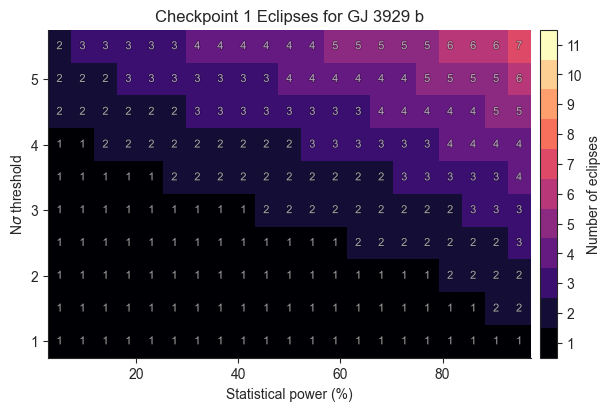

In [33]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 11,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for '+target
 )

plt.savefig('checkpoint1_gj3929b.pdf')
plt.show()

From this plot it is pretty evident that, for a $N = 3$ threshold, as the one the CIT took, 2 eclipses suffice to get to a very good statistical power of about 80\%, as we saw above. However, note how for the same statistical power, the number of eclipses rises significantly if $N$ is either 4 or 5 --- for 5 we would have needed to perform Checkpoint 1 using 5 eclipses to get a similar statistical power!

Next up, let's repeat the experiment for Checkpoint 2:

In [34]:
# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:
    
    statistical_powers_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])
    
    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_checkpoint2[i, j] = gj3929_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                     true_depth = bare_depth, 
                                                                                     target_depth = co2_depth, 
                                                                                     Nsigma = nsigma)

    np.save('sp_ch2_'+sufix+'.npy', statistical_powers)

And let's check the plot:

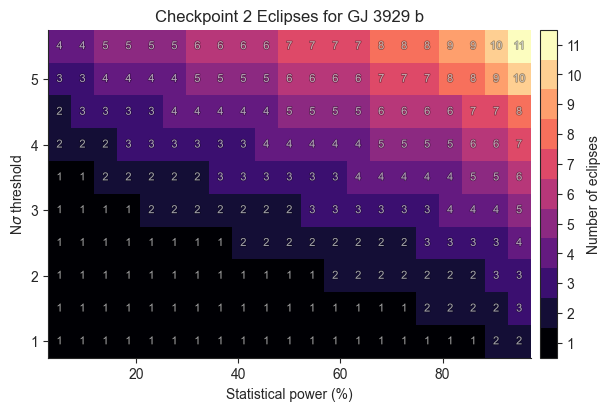

In [35]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 11,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for '+target
 )

plt.savefig('checkpoint2_gj3929b.pdf')
plt.show()

As in our experiment above (and the final CIT decision), for a threshold of $N=3\sigma$ it seems 4 eclipses is indeed the optimum to obtain a statistical power from about 80-90%. Note, however, how at $N=4$ or $5$ one would have to significantly increase the number of eclipses to about 6-8 to reach a similar statistical power.

To confirm the checkpoints, let's build a statistical power plot centered at $N_\sigma$ = 3. This, in the statistical power matrix, is located at

In [36]:
print('row index {0:}.'.format(np.where(nsigmas == 3)[0][0]))

row index 4.


Let's get the power as a function of eclipse number:

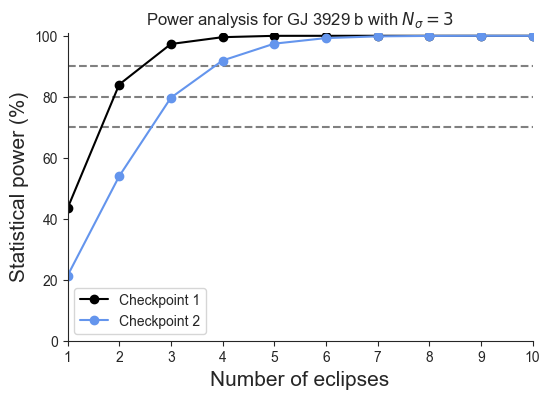

In [37]:
plt.figure(figsize=(6, 4))

plt.plot([np.min(neclipses), np.max(neclipses)], [70, 70], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [80, 80], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [90, 90], '--', color = 'grey')

plt.plot(neclipses, statistical_powers[4, :], 'o-',label = 'Checkpoint 1', color = 'black')
plt.plot(neclipses, statistical_powers_checkpoint2[4, :], 'o-',label = 'Checkpoint 2', color = 'cornflowerblue')

plt.title('Power analysis for '+target+r' with $N_{\sigma}=3$')
plt.xlabel('Number of eclipses', fontsize = 15)
plt.ylabel('Statistical power (%)', fontsize = 15)

plt.xlim( np.min(neclipses), 10 )
plt.ylim( 0, 101 )
plt.legend()

plt.show()

Let's print a table that indicates different checkpoints at different powers directly, so we don't have to stare at this plot to check the limits:

In [38]:
REVERSE = "\033[7m"
RESET = "\033[0m"

thresholds = [70, 80, 90]

In [39]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

print(f"{'N Eclipses':>12} | {'CP 1 Power (%)':>15} | {'CP 2 Power (%)':>15} | Note")
print("-" * 80)

for n, p1, p2 in zip(neclipses,
                      statistical_powers[4,:],
                      statistical_powers_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")
    
    if n > 10:
        break

  N Eclipses |  CP 1 Power (%) |  CP 2 Power (%) | Note
--------------------------------------------------------------------------------
           1 |            43.4 |            21.3 | 
           2 |            84.0 |            53.9 | CP 1 → Above 80%
           3 |            97.3 |            79.7 | CP 1 → Above 90%  CP 2 → Above 70%
           4 |            99.5 |            91.9 | CP 2 → Above 90%
           5 |           100.0 |            97.4 | 
           6 |           100.0 |            99.2 | 
           7 |           100.0 |            99.8 | 
           8 |           100.0 |           100.0 | 
           9 |           100.0 |           100.0 | 
          10 |           100.0 |           100.0 | 
          11 |           100.0 |           100.0 | 


All right --- so Checkpoint 1 should be eclipse 2 (as it was for the CIT) and Checkpoint 2 can be either eclipse 3 or 4 (was 4), depending on how much one wants to approximate. If threshold is 80% exact, should be 4 eclipses.

### 2.2 The case of LHS 1140 b

Arguably, one of the most exciting targets in the Rocky Worlds DDT is LHS 1140 b. Let's run the same simulations for this target. Let's first load the properties of this system:

In [40]:
target = 'LHS 1140 b'
time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

Let's run the Checkpoint 1 and Checkpoint 2 simulations. First, set the partial functions:

In [41]:
lhs1140b_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                              time_per_integration = time_per_integration, 
                                              observing_time = observing_time, 
                                              eclipse_duration = eclipse_duration, 
                                              noise = noise
                                             ) 

lhs1140b_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                              time_per_integration = time_per_integration, 
                                              observing_time = observing_time, 
                                              eclipse_duration = eclipse_duration, 
                                              noise = noise
                                             )

And now run the experiments:

In [42]:
neclipses = np.arange(1, 35, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers_lhs = np.zeros([ len(nsigmas), len(neclipses) ])
statistical_powers_lhs_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'lhs1140b'
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_lhs = np.load('sp_ch1_'+sufix+'.npy')
    statistical_powers_lhs_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:

    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_lhs[i, j] = lhs1140b_checkpoint1_detection_rate(neclipses = neclipse, 
                                                                               true_depth = bare_depth, 
                                                                               Nsigma = nsigma)
            
            statistical_powers_lhs_checkpoint2[i, j] = lhs1140b_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                           true_depth = bare_depth, 
                                                                                           target_depth = co2_depth, 
                                                                                           Nsigma = nsigma)
            
    np.save('sp_ch1_'+sufix+'.npy', statistical_powers_lhs)
    np.save('sp_ch2_'+sufix+'.npy', statistical_powers_lhs_checkpoint2)

Now let's plot these results:

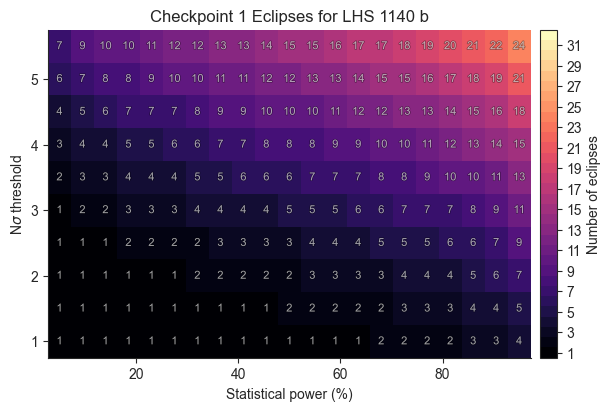

In [43]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_lhs,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 32,
     power_bins = 21,
     label_mode="cells",
     tick_jump = 2,
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for LHS 1140 b'
 )

plt.savefig('checkpoint1_lhs1140b.pdf')
plt.show()

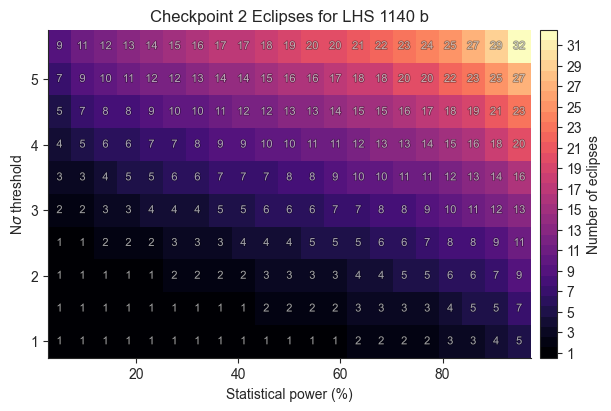

In [44]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_lhs_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 32,
     power_bins = 21,
     tick_jump = 2,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for LHS 1140 b'
 )

plt.savefig('checkpoint2_lhs1140b.pdf')
plt.show()

From these, it seems like, to have a statistical power of about $80\%$, Checkpoint 1 should be of order 8 eclipses while Checkpoint 2 should be of order 10 eclipses. Lets confirm this by exploring the statistical power matrix we obtained above, just like we did for GJ 3929 b:

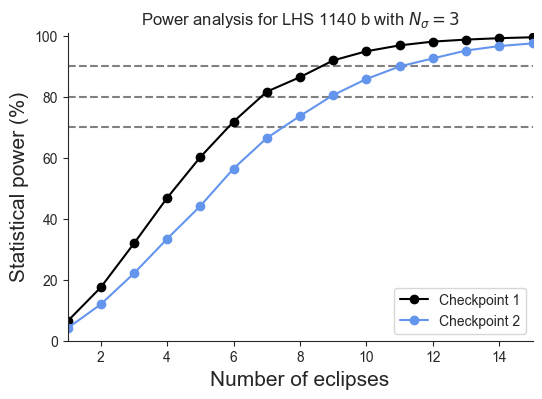

In [45]:
plt.figure(figsize=(6, 4))

plt.plot([np.min(neclipses), np.max(neclipses)], [70, 70], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [80, 80], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [90, 90], '--', color = 'grey')

plt.plot(neclipses, statistical_powers_lhs[4, :], 'o-',label = 'Checkpoint 1', color = 'black')
plt.plot(neclipses, statistical_powers_lhs_checkpoint2[4, :], 'o-',label = 'Checkpoint 2', color = 'cornflowerblue')

plt.title('Power analysis for '+target+r' with $N_{\sigma}=3$')
plt.xlabel('Number of eclipses', fontsize = 15)
plt.ylabel('Statistical power (%)', fontsize = 15)

plt.xlim( np.min(neclipses), 15 )
plt.ylim( 0, 101 )
plt.legend()

plt.show()

Let's print for easier visualization:

In [46]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

print(f"{'N Eclipses':>12} | {'CP 1 Power (%)':>15} | {'CP 2 Power (%)':>15} | Note")
print("-" * 80)

for n, p1, p2 in zip(neclipses,
                      statistical_powers_lhs[4,:],
                      statistical_powers_lhs_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")
    
    if n > 16:
        break

  N Eclipses |  CP 1 Power (%) |  CP 2 Power (%) | Note
--------------------------------------------------------------------------------
           1 |             6.4 |             4.1 | 
           2 |            17.5 |            11.9 | 
           3 |            31.9 |            22.1 | 
           4 |            46.9 |            33.4 | 
           5 |            60.2 |            44.2 | 
           6 |            71.9 |            56.5 | CP 1 → Above 70%
           7 |            81.7 |            66.5 | CP 1 → Above 80%
           8 |            86.4 |            73.7 | CP 2 → Above 70%
           9 |            91.9 |            80.6 | CP 1 → Above 90%  CP 2 → Above 80%
          10 |            94.9 |            85.8 | 
          11 |            96.9 |            90.0 | 
          12 |            98.1 |            92.6 | CP 2 → Above 90%
          13 |            98.8 |            95.2 | 
          14 |            99.2 |            96.6 | 
          15 |            99.5 |     

Indeed --- for 7 eclipses on Checkpoint 1 and 9 eclipses in Checkpoint 2, you get at 80\% power for LHS 1140 b.

### 2.3 The case of TOI-198 b

Another of the exciting targets is TOI-198~b. This is a special target in the sense that, from an order of magnitude standpoint, it needs a large number of eclipses. Let us run calculations for this one and study the results:

In [47]:
target = 'TOI-198 b'
time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

In [48]:
toi198b_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             ) 

toi198b_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             )

In [49]:
neclipses = np.arange(1, 75, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers_toi198 = np.zeros([ len(nsigmas), len(neclipses) ])
statistical_powers_toi198_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'toi198b'
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_toi198 = np.load('sp_ch1_'+sufix+'.npy')
    statistical_powers_toi198_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:

    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_toi198[i, j] = toi198b_checkpoint1_detection_rate(neclipses = neclipse, 
                                                                               true_depth = bare_depth, 
                                                                               Nsigma = nsigma)
            
            statistical_powers_toi198_checkpoint2[i, j] = toi198b_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                           true_depth = bare_depth, 
                                                                                           target_depth = co2_depth, 
                                                                                           Nsigma = nsigma)
    
    np.save('sp_ch1_'+sufix+'.npy', statistical_powers_toi198)
    np.save('sp_ch2_'+sufix+'.npy', statistical_powers_toi198_checkpoint2)

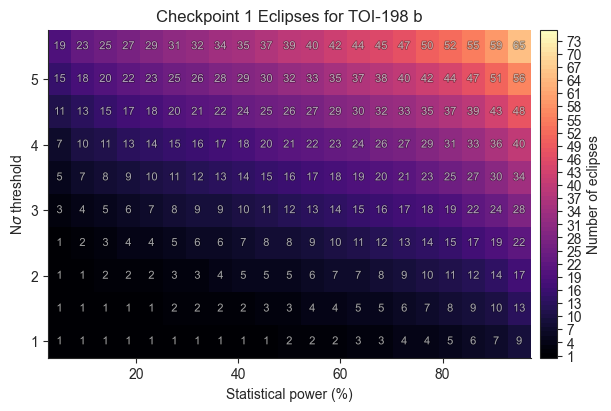

In [50]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_toi198,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 75,
     tick_jump = 3,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for TOI-198 b'
 )

plt.savefig('checkpoint1_toi198b.pdf')
plt.show()

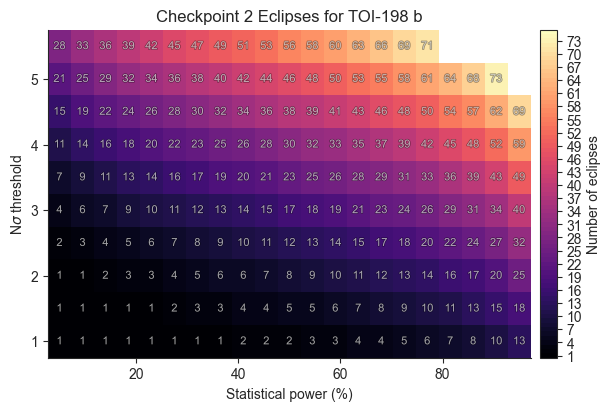

In [51]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_toi198_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 75,
     tick_jump = 3,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for TOI-198 b'
 )

plt.savefig('checkpoint2_toi198b.pdf')
plt.show()

It seems this power analysis suggests a lot more eclipses for this one. Let's lock the plot at N = 3:

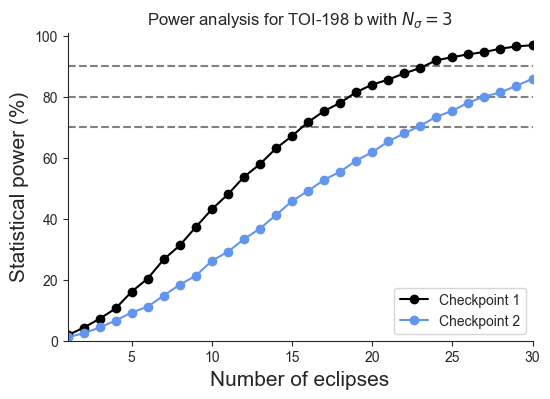

In [52]:
plt.figure(figsize=(6, 4))

plt.plot([np.min(neclipses), np.max(neclipses)], [70, 70], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [80, 80], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [90, 90], '--', color = 'grey')

plt.plot(neclipses, statistical_powers_toi198[4, :], 'o-',label = 'Checkpoint 1', color = 'black')
plt.plot(neclipses, statistical_powers_toi198_checkpoint2[4, :], 'o-',label = 'Checkpoint 2', color = 'cornflowerblue')

plt.title('Power analysis for '+target+r' with $N_{\sigma}=3$')
plt.xlabel('Number of eclipses', fontsize = 15)
plt.ylabel('Statistical power (%)', fontsize = 15)

plt.xlim( np.min(neclipses), 30 )
plt.ylim( 0, 101 )
plt.legend()

plt.show()

By eye, it seems of order 26 eclipses for Checkpoint 2, and 19 for Checkpoint 2. Let's look at the table:

In [53]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

print(f"{'N Eclipses':>12} | {'CP 1 Power (%)':>15} | {'CP 2 Power (%)':>15} | Note")
print("-" * 80)

for n, p1, p2 in zip(neclipses,
                      statistical_powers_toi198[4,:],
                      statistical_powers_toi198_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")
    
    if n > 50:
        break

  N Eclipses |  CP 1 Power (%) |  CP 2 Power (%) | Note
--------------------------------------------------------------------------------
           1 |             1.8 |             1.2 | 
           2 |             4.3 |             2.4 | 
           3 |             7.2 |             4.3 | 
           4 |            10.6 |             6.6 | 
           5 |            16.1 |             9.2 | 
           6 |            20.4 |            11.2 | 
           7 |            26.7 |            14.8 | 
           8 |            31.2 |            18.4 | 
           9 |            37.3 |            21.3 | 
          10 |            43.1 |            26.2 | 
          11 |            48.0 |            29.2 | 
          12 |            53.7 |            33.3 | 
          13 |            57.9 |            36.8 | 
          14 |            63.1 |            41.2 | 
          15 |            67.1 |            45.8 | 
          16 |            71.7 |            49.1 | CP 1 → Above 70%
          17 | 

Indeed, for this target, much harder to get above $80\%$. For Checkpoint 1 you get there at 19 eclipses, for Checkpoint 2 you get there at 28 eclipses.

### 2.4 The case of TOI-406 c

Let's move to TOI-406 c next:

In [54]:
target = 'TOI-406 c'
time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

In [55]:
toi406c_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             ) 

toi406c_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             )

In [56]:
neclipses = np.arange(1, 30, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers_toi406c = np.zeros([ len(nsigmas), len(neclipses) ])
statistical_powers_toi406c_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'toi406c'
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_toi406c = np.load('sp_ch1_'+sufix+'.npy')
    statistical_powers_toi406c_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:


    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_toi406c[i, j] = toi406c_checkpoint1_detection_rate(neclipses = neclipse, 
                                                                               true_depth = bare_depth, 
                                                                               Nsigma = nsigma)
            
            statistical_powers_toi406c_checkpoint2[i, j] = toi406c_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                           true_depth = bare_depth, 
                                                                                           target_depth = co2_depth, 
                                                                                           Nsigma = nsigma)
    
    np.save('sp_ch1_'+sufix+'.npy', statistical_powers_toi406c)
    np.save('sp_ch2_'+sufix+'.npy', statistical_powers_toi406c_checkpoint2)

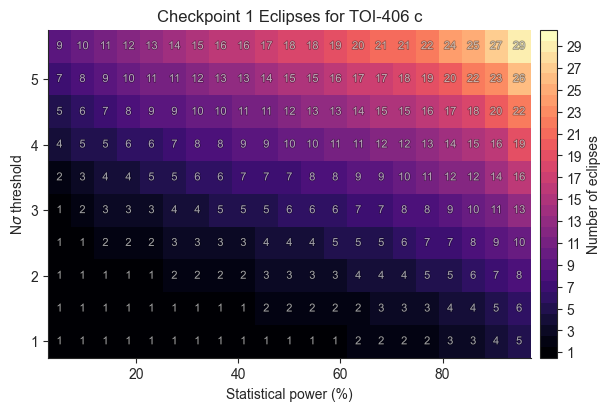

In [57]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_toi406c,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 30,
     power_bins = 21,
     tick_jump = 2,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for TOI-406 c'
 )

plt.savefig('checkpoint1_toi406c.pdf')
plt.show()

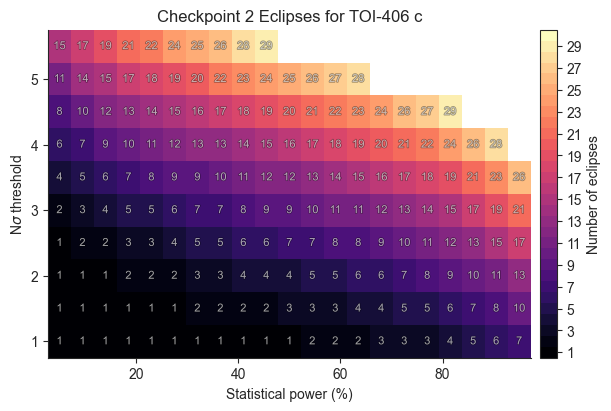

In [58]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_toi406c_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 30,
     power_bins = 21,
     tick_jump = 2,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for TOI-406 c'
 )

plt.savefig('checkpoint2_toi406c.pdf')
plt.show()

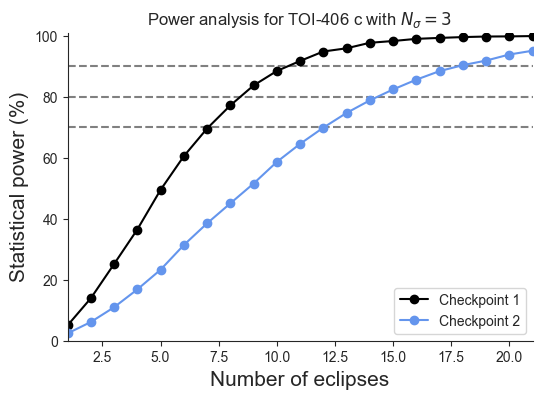

In [59]:
plt.figure(figsize=(6, 4))

plt.plot([np.min(neclipses), np.max(neclipses)], [70, 70], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [80, 80], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [90, 90], '--', color = 'grey')

plt.plot(neclipses, statistical_powers_toi406c[4, :], 'o-',label = 'Checkpoint 1', color = 'black')
plt.plot(neclipses, statistical_powers_toi406c_checkpoint2[4, :], 'o-',label = 'Checkpoint 2', color = 'cornflowerblue')

plt.title('Power analysis for '+target+r' with $N_{\sigma}=3$')
plt.xlabel('Number of eclipses', fontsize = 15)
plt.ylabel('Statistical power (%)', fontsize = 15)

plt.xlim( np.min(neclipses), 21 )
plt.ylim( 0, 101 )
plt.legend()

plt.show()

In [60]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

print(f"{'N Eclipses':>12} | {'CP 1 Power (%)':>15} | {'CP 2 Power (%)':>15} | Note")
print("-" * 80)

for n, p1, p2 in zip(neclipses,
                      statistical_powers_toi406c[4,:],
                      statistical_powers_toi406c_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")
    
    if n > 20:
        break

  N Eclipses |  CP 1 Power (%) |  CP 2 Power (%) | Note
--------------------------------------------------------------------------------
           1 |             5.0 |             2.4 | 
           2 |            13.9 |             6.1 | 
           3 |            25.1 |            11.0 | 
           4 |            36.5 |            16.8 | 
           5 |            49.5 |            23.3 | 
           6 |            60.5 |            31.4 | 
           7 |            69.6 |            38.5 | 
           8 |            77.1 |            45.0 | CP 1 → Above 70%
           9 |            83.7 |            51.5 | CP 1 → Above 80%
          10 |            88.4 |            58.6 | 
          11 |            91.7 |            64.5 | CP 1 → Above 90%
          12 |            94.8 |            69.9 | 
          13 |            95.9 |            74.7 | CP 2 → Above 70%
          14 |            97.7 |            78.8 | 
          15 |            98.3 |            82.4 | CP 2 → Above 80%
   

For this one is also hard to move to $80\%$ --- for Checkpoint 1, this happens at 9 eclipses, for Checkpoint 2 at 15 eclipses.

### 2.5 The case for LTT 1445 A b

In [61]:
target = 'LTT 1445 A b'
time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

In [62]:
ltt1445Ab_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             ) 

ltt1445Ab_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             )

neclipses = np.arange(1, 15, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers_ltt1445Ab = np.zeros([ len(nsigmas), len(neclipses) ])
statistical_powers_ltt1445Ab_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'ltt1445Ab'
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_ltt1445Ab = np.load('sp_ch1_'+sufix+'.npy')
    statistical_powers_ltt1445Ab_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:


    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_ltt1445Ab[i, j] = ltt1445Ab_checkpoint1_detection_rate(neclipses = neclipse, 
                                                                               true_depth = bare_depth, 
                                                                               Nsigma = nsigma)
            
            statistical_powers_ltt1445Ab_checkpoint2[i, j] = ltt1445Ab_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                           true_depth = bare_depth, 
                                                                                           target_depth = co2_depth, 
                                                                                           Nsigma = nsigma)
    
    np.save('sp_ch1_'+sufix+'.npy', statistical_powers_ltt1445Ab)
    np.save('sp_ch2_'+sufix+'.npy', statistical_powers_ltt1445Ab_checkpoint2)

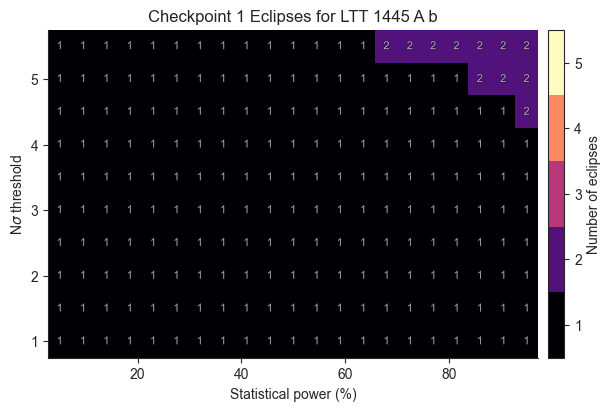

In [63]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_ltt1445Ab,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 5,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for '+target
 )

plt.savefig('checkpoint1_'+sufix+'.pdf')
plt.show()

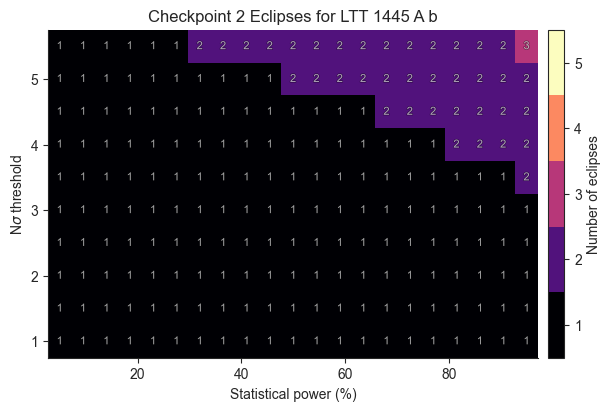

In [64]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_ltt1445Ab_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 5,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for '+target
 )

plt.savefig('checkpoint2_'+sufix+'.pdf')
plt.show()

For this target we don't even need a plot:

In [65]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

for n, p1, p2 in zip(neclipses,
                      statistical_powers_ltt1445Ab[4,:],
                      statistical_powers_ltt1445Ab_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")

           1 |            99.9 |            97.2 | CP 1 → Above 90%  CP 2 → Above 90%
           2 |           100.0 |           100.0 | 
           3 |           100.0 |           100.0 | 
           4 |           100.0 |           100.0 | 
           5 |           100.0 |           100.0 | 
           6 |           100.0 |           100.0 | 
           7 |           100.0 |           100.0 | 
           8 |           100.0 |           100.0 | 
           9 |           100.0 |           100.0 | 
          10 |           100.0 |           100.0 | 
          11 |           100.0 |           100.0 | 
          12 |           100.0 |           100.0 | 
          13 |           100.0 |           100.0 | 
          14 |           100.0 |           100.0 | 


A single eclipse should be enough!

### 2.6 The case for LTT 1445 A c

In [66]:
target = 'LTT 1445 A c'
time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

In [67]:
ltt1445Ac_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             ) 

ltt1445Ac_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             )

neclipses = np.arange(1, 15, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers_ltt1445Ac = np.zeros([ len(nsigmas), len(neclipses) ])
statistical_powers_ltt1445Ac_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'ltt1445Ac'
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_ltt1445Ac = np.load('sp_ch1_'+sufix+'.npy')
    statistical_powers_ltt1445Ac_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:


    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_ltt1445Ac[i, j] = ltt1445Ac_checkpoint1_detection_rate(neclipses = neclipse, 
                                                                               true_depth = bare_depth, 
                                                                               Nsigma = nsigma)
            
            statistical_powers_ltt1445Ac_checkpoint2[i, j] = ltt1445Ac_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                           true_depth = bare_depth, 
                                                                                           target_depth = co2_depth, 
                                                                                           Nsigma = nsigma)
    
    np.save('sp_ch1_'+sufix+'.npy', statistical_powers_ltt1445Ac)
    np.save('sp_ch2_'+sufix+'.npy', statistical_powers_ltt1445Ac_checkpoint2)

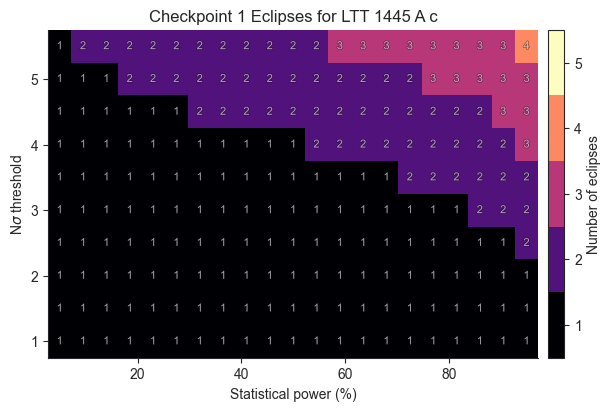

In [68]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_ltt1445Ac,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 5,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for '+target
 )

plt.savefig('checkpoint1_'+sufix+'.pdf')
plt.show()

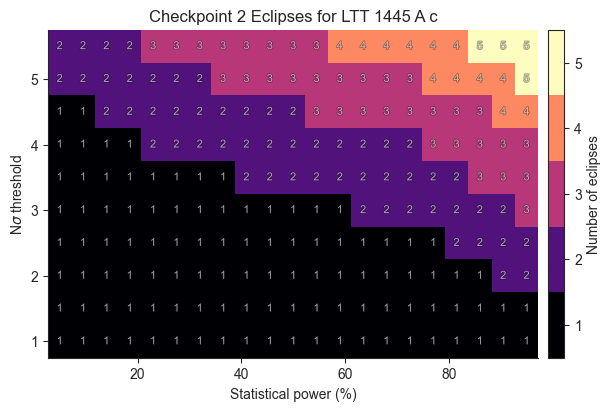

In [69]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_ltt1445Ac_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 5,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for '+target
 )

plt.savefig('checkpoint2_'+sufix+'.pdf')
plt.show()

Let's check those plots for this target:

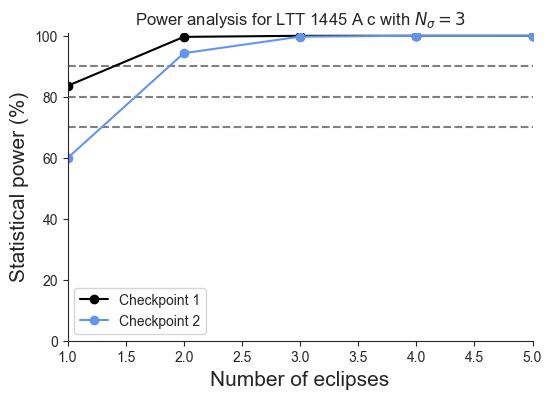

In [70]:
plt.figure(figsize=(6, 4))

plt.plot([np.min(neclipses), np.max(neclipses)], [70, 70], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [80, 80], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [90, 90], '--', color = 'grey')

plt.plot(neclipses, statistical_powers_ltt1445Ac[4, :], 'o-',label = 'Checkpoint 1', color = 'black')
plt.plot(neclipses, statistical_powers_ltt1445Ac_checkpoint2[4, :], 'o-',label = 'Checkpoint 2', color = 'cornflowerblue')

plt.title('Power analysis for '+target+r' with $N_{\sigma}=3$')
plt.xlabel('Number of eclipses', fontsize = 15)
plt.ylabel('Statistical power (%)', fontsize = 15)

plt.xlim( np.min(neclipses), 5 )
plt.ylim( 0, 101 )
plt.legend()

plt.show()

And the table:

In [71]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

print(f"{'N Eclipses':>12} | {'CP 1 Power (%)':>15} | {'CP 2 Power (%)':>15} | Note")
print("-" * 80)

for n, p1, p2 in zip(neclipses,
                      statistical_powers_ltt1445Ac[4,:],
                      statistical_powers_ltt1445Ac_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")

  N Eclipses |  CP 1 Power (%) |  CP 2 Power (%) | Note
--------------------------------------------------------------------------------
           1 |            83.6 |            59.9 | CP 1 → Above 80%
           2 |            99.6 |            94.3 | CP 1 → Above 90%  CP 2 → Above 90%
           3 |           100.0 |            99.7 | 
           4 |           100.0 |           100.0 | 
           5 |           100.0 |           100.0 | 
           6 |           100.0 |           100.0 | 
           7 |           100.0 |           100.0 | 
           8 |           100.0 |           100.0 | 
           9 |           100.0 |           100.0 | 
          10 |           100.0 |           100.0 | 
          11 |           100.0 |           100.0 | 
          12 |           100.0 |           100.0 | 
          13 |           100.0 |           100.0 | 
          14 |           100.0 |           100.0 | 


For this target, Checkpoint 1 would be one eclipse --- Checkpoint 2 two eclipses.

### 2.7 The case for TOI-771 b

In [72]:
target = 'TOI-771 b'
time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

In [73]:
toi771b_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             ) 

toi771b_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             )

neclipses = np.arange(1, 15, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers_toi771b = np.zeros([ len(nsigmas), len(neclipses) ])
statistical_powers_toi771b_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'toi771b'
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_toi771b = np.load('sp_ch1_'+sufix+'.npy')
    statistical_powers_toi771b_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:


    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_toi771b[i, j] = toi771b_checkpoint1_detection_rate(neclipses = neclipse, 
                                                                               true_depth = bare_depth, 
                                                                               Nsigma = nsigma)
            
            statistical_powers_toi771b_checkpoint2[i, j] = toi771b_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                           true_depth = bare_depth, 
                                                                                           target_depth = co2_depth, 
                                                                                           Nsigma = nsigma)
    
    np.save('sp_ch1_'+sufix+'.npy', statistical_powers_toi771b)
    np.save('sp_ch2_'+sufix+'.npy', statistical_powers_toi771b_checkpoint2)

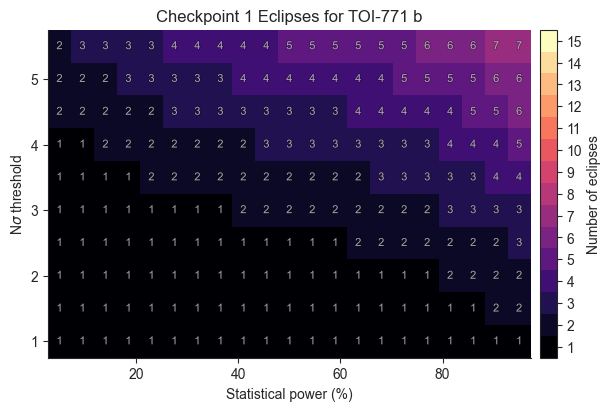

In [74]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_toi771b,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 15,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for '+target
 )

plt.savefig('checkpoint1_'+sufix+'.pdf')
plt.show()

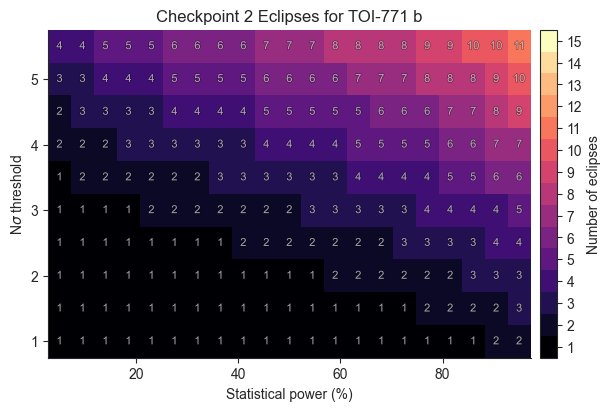

In [75]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_toi771b_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 15,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for '+target
 )

plt.savefig('checkpoint2_'+sufix+'.pdf')
plt.show()

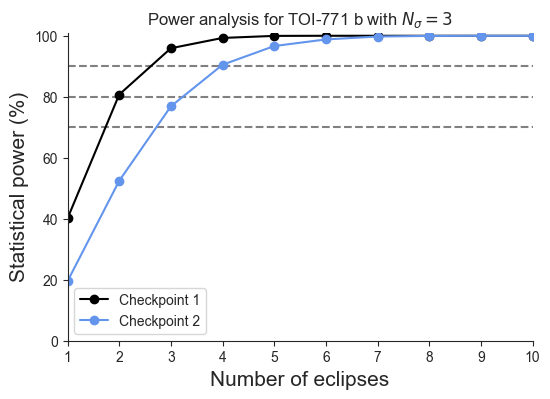

In [76]:
plt.figure(figsize=(6, 4))

plt.plot([np.min(neclipses), np.max(neclipses)], [70, 70], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [80, 80], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [90, 90], '--', color = 'grey')

plt.plot(neclipses, statistical_powers_toi771b[4, :], 'o-',label = 'Checkpoint 1', color = 'black')
plt.plot(neclipses, statistical_powers_toi771b_checkpoint2[4, :], 'o-',label = 'Checkpoint 2', color = 'cornflowerblue')

plt.title('Power analysis for '+target+r' with $N_{\sigma}=3$')
plt.xlabel('Number of eclipses', fontsize = 15)
plt.ylabel('Statistical power (%)', fontsize = 15)

plt.xlim( np.min(neclipses), 10 )
plt.ylim( 0, 101 )
plt.legend()

plt.show()

In [77]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

print(f"{'N Eclipses':>12} | {'CP 1 Power (%)':>15} | {'CP 2 Power (%)':>15} | Note")
print("-" * 80)

for n, p1, p2 in zip(neclipses,
                      statistical_powers_toi771b[4,:],
                      statistical_powers_toi771b_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")

  N Eclipses |  CP 1 Power (%) |  CP 2 Power (%) | Note
--------------------------------------------------------------------------------
           1 |            40.1 |            19.5 | 
           2 |            80.7 |            52.4 | CP 1 → Above 80%
           3 |            95.9 |            76.8 | CP 1 → Above 90%  CP 2 → Above 70%
           4 |            99.3 |            90.5 | CP 2 → Above 90%
           5 |           100.0 |            96.6 | 
           6 |           100.0 |            98.8 | 
           7 |           100.0 |            99.8 | 
           8 |           100.0 |           100.0 | 
           9 |           100.0 |           100.0 | 
          10 |           100.0 |           100.0 | 
          11 |           100.0 |           100.0 | 
          12 |           100.0 |           100.0 | 
          13 |           100.0 |           100.0 | 
          14 |           100.0 |           100.0 | 


For this target, Checkpoint 1 is 2 eclipses, Checkpoint 2 is 4 eclipses.

### 2.8 The case for HD 260655 c

In [78]:
target = 'HD 260655 c'
time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

In [79]:
hd260655c_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             ) 

hd260655c_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             )

neclipses = np.arange(1, 15, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers_hd260655c = np.zeros([ len(nsigmas), len(neclipses) ])
statistical_powers_hd260655c_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'hd260655c'
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_hd260655c = np.load('sp_ch1_'+sufix+'.npy')
    statistical_powers_hd260655c_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:


    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_hd260655c[i, j] = hd260655c_checkpoint1_detection_rate(neclipses = neclipse, 
                                                                               true_depth = bare_depth, 
                                                                               Nsigma = nsigma)
            
            statistical_powers_hd260655c_checkpoint2[i, j] = hd260655c_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                           true_depth = bare_depth, 
                                                                                           target_depth = co2_depth, 
                                                                                           Nsigma = nsigma)
    
    np.save('sp_ch1_'+sufix+'.npy', statistical_powers_hd260655c)
    np.save('sp_ch2_'+sufix+'.npy', statistical_powers_hd260655c_checkpoint2)

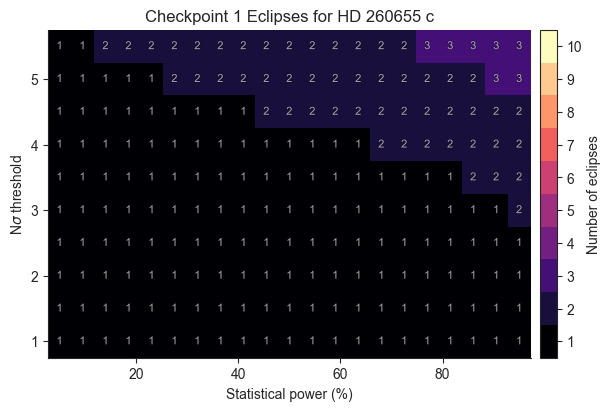

In [80]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_hd260655c,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 10,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for '+target
 )

plt.savefig('checkpoint1_'+sufix+'.pdf')
plt.show()

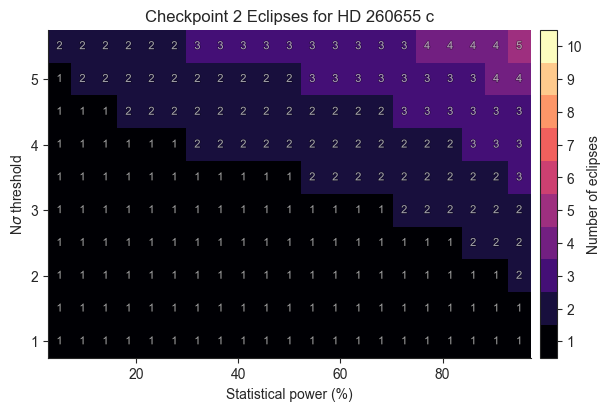

In [81]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_hd260655c_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 10,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for '+target
 )

plt.savefig('checkpoint2_'+sufix+'.pdf')
plt.show()

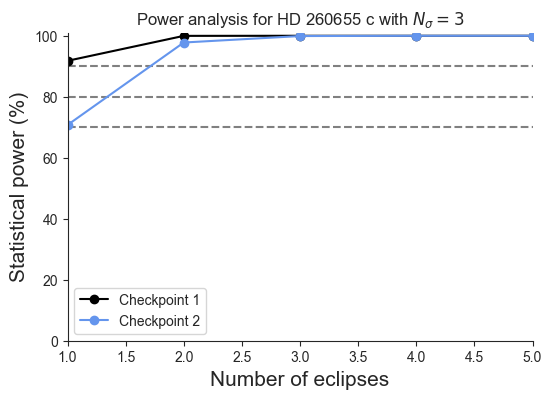

In [82]:
plt.figure(figsize=(6, 4))

plt.plot([np.min(neclipses), np.max(neclipses)], [70, 70], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [80, 80], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [90, 90], '--', color = 'grey')

plt.plot(neclipses, statistical_powers_hd260655c[4, :], 'o-',label = 'Checkpoint 1', color = 'black')
plt.plot(neclipses, statistical_powers_hd260655c_checkpoint2[4, :], 'o-',label = 'Checkpoint 2', color = 'cornflowerblue')

plt.title('Power analysis for '+target+r' with $N_{\sigma}=3$')
plt.xlabel('Number of eclipses', fontsize = 15)
plt.ylabel('Statistical power (%)', fontsize = 15)

plt.xlim( np.min(neclipses), 5 )
plt.ylim( 0, 101 )
plt.legend()

plt.show()

In [83]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

print(f"{'N Eclipses':>12} | {'CP 1 Power (%)':>15} | {'CP 2 Power (%)':>15} | Note")
print("-" * 80)

for n, p1, p2 in zip(neclipses,
                      statistical_powers_hd260655c[4,:],
                      statistical_powers_hd260655c_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")

  N Eclipses |  CP 1 Power (%) |  CP 2 Power (%) | Note
--------------------------------------------------------------------------------
           1 |            91.8 |            70.8 | CP 1 → Above 90%  CP 2 → Above 70%
           2 |           100.0 |            97.8 | CP 2 → Above 90%
           3 |           100.0 |            99.9 | 
           4 |           100.0 |           100.0 | 
           5 |           100.0 |           100.0 | 
           6 |           100.0 |           100.0 | 
           7 |           100.0 |           100.0 | 
           8 |           100.0 |           100.0 | 
           9 |           100.0 |           100.0 | 
          10 |           100.0 |           100.0 | 
          11 |           100.0 |           100.0 | 
          12 |           100.0 |           100.0 | 
          13 |           100.0 |           100.0 | 
          14 |           100.0 |           100.0 | 


For this target, Checkpoint 1 is 1 eclipse, 2 is 2 eclipses.

### 2.9 The case for TOI-244 b

In [84]:
target = 'TOI-244 b'
time_per_integration = CIT_calculations[target]['time per integration']
observing_time = CIT_calculations[target]['observing time']
eclipse_duration = CIT_calculations[target]['eclipse duration']
bare_depth = CIT_calculations[target]['bare rock depth']
co2_depth = CIT_calculations[target]['CO2 depth']
noise_per_integration = CIT_calculations[target]['precision per integration']
eclipse_error = CIT_calculations[target]['eclipse error']

In [85]:
toi244b_checkpoint1_detection_rate = partial(checkpoint1_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             ) 

toi244b_checkpoint2_detection_rate = partial(checkpoint2_detection_rate, 
                                             time_per_integration = time_per_integration, 
                                             observing_time = observing_time, 
                                             eclipse_duration = eclipse_duration, 
                                             noise = noise
                                             )

neclipses = np.arange(1, 15, 1)
nsigmas = np.arange(1, 6, 0.5)
statistical_powers_toi244b = np.zeros([ len(nsigmas), len(neclipses) ])
statistical_powers_toi244b_checkpoint2 = np.zeros([ len(nsigmas), len(neclipses) ])

# Load results if available; if not, run the experiment. This takes a while to run (about an hour)!
sufix = 'toi244b'
if os.path.exists('sp_ch2_'+sufix+'.npy'):

    statistical_powers_toi244b = np.load('sp_ch1_'+sufix+'.npy')
    statistical_powers_toi244b_checkpoint2 = np.load('sp_ch2_'+sufix+'.npy')

else:


    for i in range(len(nsigmas)):
    
        nsigma = nsigmas[i]
        for j in range(len(neclipses)): 
            
            neclipse = neclipses[j]
            statistical_powers_toi244b[i, j] = toi244b_checkpoint1_detection_rate(neclipses = neclipse, 
                                                                               true_depth = bare_depth, 
                                                                               Nsigma = nsigma)
            
            statistical_powers_toi244b_checkpoint2[i, j] = toi244b_checkpoint2_detection_rate(neclipses = neclipse, 
                                                                                           true_depth = bare_depth, 
                                                                                           target_depth = co2_depth, 
                                                                                           Nsigma = nsigma)
    
    np.save('sp_ch1_'+sufix+'.npy', statistical_powers_toi244b)
    np.save('sp_ch2_'+sufix+'.npy', statistical_powers_toi244b_checkpoint2)

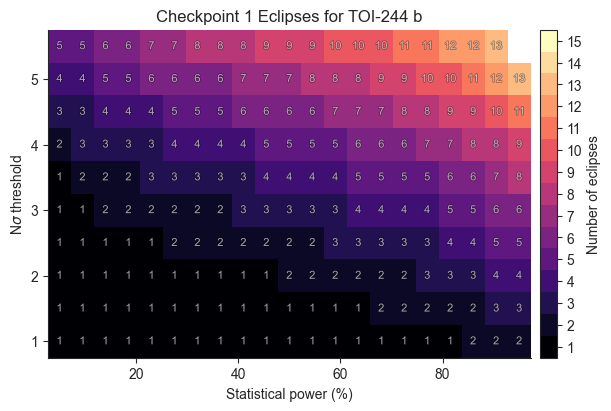

In [86]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_toi244b,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 15,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 1 Eclipses for '+target
 )

plt.savefig('checkpoint1_'+sufix+'.pdf')
plt.show()

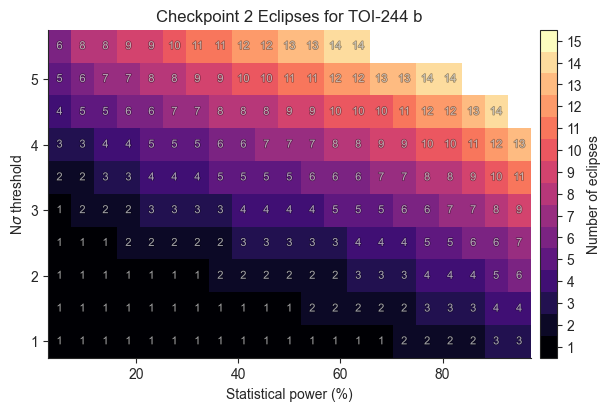

In [87]:
fig, ax, cbar, req_eclipses, power_grid = plot_eclipses_needed_vs_power(
     statistical_powers=statistical_powers_toi244b_checkpoint2,
     nsigmas=nsigmas,
     neclipses=neclipses,
     power_grid=np.linspace(0, 100, 250),
     cmap="magma",
     max_eclipse = 15,
     power_bins = 21,
     label_mode="cells",
     show_boundaries=False,
     power_min = 5,
     power_max = 95, 
     title = 'Checkpoint 2 Eclipses for '+target
 )

plt.savefig('checkpoint2_'+sufix+'.pdf')
plt.show()

Finally, for this target the results say:

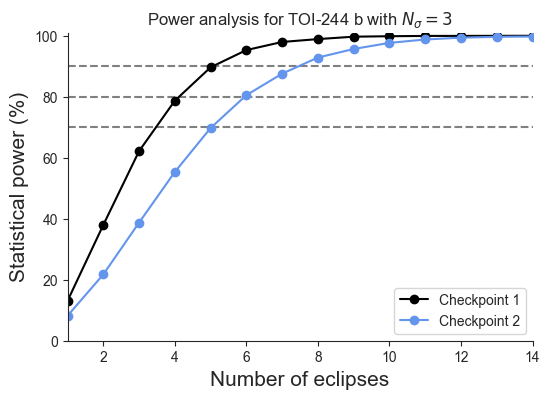

In [88]:
plt.figure(figsize=(6, 4))

plt.plot([np.min(neclipses), np.max(neclipses)], [70, 70], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [80, 80], '--', color = 'grey')
plt.plot([np.min(neclipses), np.max(neclipses)], [90, 90], '--', color = 'grey')

plt.plot(neclipses, statistical_powers_toi244b[4, :], 'o-',label = 'Checkpoint 1', color = 'black')
plt.plot(neclipses, statistical_powers_toi244b_checkpoint2[4, :], 'o-',label = 'Checkpoint 2', color = 'cornflowerblue')

plt.title('Power analysis for '+target+r' with $N_{\sigma}=3$')
plt.xlabel('Number of eclipses', fontsize = 15)
plt.ylabel('Statistical power (%)', fontsize = 15)

plt.xlim( np.min(neclipses), 14 )
plt.ylim( 0, 101 )
plt.legend()

plt.show()

In [89]:
crossed_t1 = {thr: False for thr in thresholds}
crossed_t2 = {thr: False for thr in thresholds}

print(f"{'N Eclipses':>12} | {'CP 1 Power (%)':>15} | {'CP 2 Power (%)':>15} | Note")
print("-" * 80)

for n, p1, p2 in zip(neclipses,
                      statistical_powers_toi244b[4,:],
                      statistical_powers_toi244b_checkpoint2[4,:]):

    note_parts = []
    triggered_row = False

    # default strings
    n_int = int(n)
    n_str = f"{n_int:12d}"
    p1_str = f"{p1:15.1f}"
    p2_str = f"{p2:15.1f}"

    # ---- Test 1: find newly beaten thresholds ----
    newly_t1 = [thr for thr in thresholds if (p1 >= thr) and (not crossed_t1[thr])]
    if newly_t1:
        triggered_row = True
        thr_max = max(newly_t1)
        p1_str = f"{REVERSE}{p1:15.1f}{RESET}"
        note_parts.append(f"CP 1 → Above {thr_max}%")
        # mark all newly crossed thresholds as crossed
        for thr in newly_t1:
            crossed_t1[thr] = True

    # ---- Test 2: find newly beaten thresholds ----
    newly_t2 = [thr for thr in thresholds if (p2 >= thr) and (not crossed_t2[thr])]
    if newly_t2:
        triggered_row = True
        thr_max = max(newly_t2)
        p2_str = f"{REVERSE}{p2:15.1f}{RESET}"
        note_parts.append(f"CP 2 → Above {thr_max}%")
        for thr in newly_t2:
            crossed_t2[thr] = True

    # If either test crossed something new, reverse-highlight N eclipses too
    if triggered_row:
        n_str = f"{REVERSE}{n_int:12d}{RESET}"

    note = "  ".join(note_parts)
    print(f"{n_str} | {p1_str} | {p2_str} | {note}")

  N Eclipses |  CP 1 Power (%) |  CP 2 Power (%) | Note
--------------------------------------------------------------------------------
           1 |            13.1 |             8.2 | 
           2 |            38.0 |            21.7 | 
           3 |            62.2 |            38.7 | 
           4 |            78.7 |            55.3 | CP 1 → Above 70%
           5 |            89.7 |            69.8 | CP 1 → Above 80%
           6 |            95.3 |            80.5 | CP 1 → Above 90%  CP 2 → Above 80%
           7 |            98.0 |            87.6 | 
           8 |            98.9 |            92.9 | CP 2 → Above 90%
           9 |            99.7 |            95.7 | 
          10 |            99.9 |            97.7 | 
          11 |           100.0 |            98.8 | 
          12 |           100.0 |            99.4 | 
          13 |           100.0 |            99.7 | 
          14 |           100.0 |            99.8 | 


For this target, Checkpoint 1 should be 4 or 5 eclipses (depending on cut of decimals, will move with 5 if threshold is 80%). For Checkpoint 2, 6 eclipses seems to do the trick. 

***

<table style="width:100%; border:0;">
<tr>
<td style="text-align:left; vertical-align:middle;">
<a href="#top">Top of Page</a>
</td>

<td style="text-align:right; vertical-align:middle;">
<img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/7f391657bc2bf47a784400d65d2882703787416d/stsci_logo2.png"
     alt="Space Telescope Logo"
     width="80px"/>
</td>
</tr>
</table>